
#  Workshop 2: Basic classification Task with a Multi-Layer Perceptron (MLP): Computer Vision Applications

In this lab, you will train a multi-layer artificial neural network to classify handwritten digits from the MNIST dataset. The goal is to understand the full pipeline: data → model → training → evaluation → prediction

This program learns to recognize handwritten digits using stochastic gradient descent and the MNIST training data, employing neural network libraries. The goal is to find the best architecture and hyperparameters to achieve the highest accuracy.

The MNIST Dataset contains:

- 60,000 training images
- 10,000 test images
- Each image is 28 × 28 pixels
- Each label is a digit from 0 to 9

So, this is a 10-class classification problem.

# **Step 1: Import Libraries.**

Libraries provide:

- TensorFlow/Keras → neural networks
- NumPy → numerical operations
- Matplotlib → visualisation

In [17]:
import tensorflow as tf
import numpy as np
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras import regularizers
from matplotlib import pyplot as plt



# **Step 2: Import the dataset and split it into training and test sets.**

Why normalisation?

Pixel values are originally in [0, 255].
Neural networks learn better when inputs are in [0, 1].

In [18]:
# MNIST data
numClasses = 10

(xTrain, yTrain), (xTest, yTest) = mnist.load_data()

xTrain = xTrain.astype(np.float32) / 255.0
xTest  = xTest.astype(np.float32) / 255.0

yTrain_oh = tf.one_hot(yTrain, depth=numClasses)
yTest_oh  = tf.one_hot(yTest, depth=numClasses)

print(xTrain.shape, yTrain.shape, xTest.shape, yTest.shape)
print(yTrain_oh.shape, yTest_oh.shape)


(60000, 28, 28) (60000,) (10000, 28, 28) (10000,)
(60000, 10) (10000, 10)


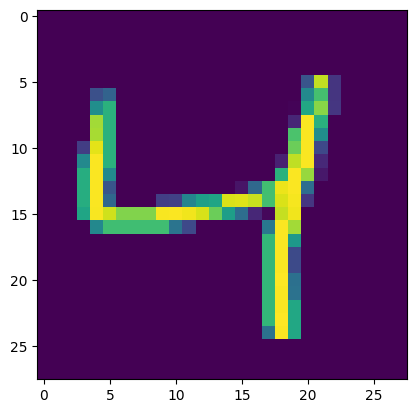

In [19]:
plt.imshow(xTrain[2,:,:])

# Step 3: Define the model

2. Hidden layer (Dense) learns internal features such as:

- strokes
- curves
- edges
- ReLU introduces non-linearity.

3. Output layer (Dense 10 + Softmax): Produces probabilities for each digit

In [20]:
layers = [
    tf.keras.layers.Flatten(input_shape=(28, 28)),                 # Input
    # tf.keras.layers.Dense(40, activation='relu',
    #                       kernel_regularizer=regularizers.l2(0.01)), # Hidden
    tf.keras.layers.Dense(5, activation='relu'), # Hidden
    tf.keras.layers.Dense(10),                                      # Logits
    tf.keras.layers.Softmax()                                       # Probabilities
]
model = Sequential(layers)


In [21]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_2 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 5)              │         3,925 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │            60 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ softmax_2 (Softmax)             │ (None, 10)             │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,985 (15.57 KB)

 Trainable params: 3,985 (15.57 KB)

 Non-trainable params: 0 (0.00 B)

# Step 4: Configure the model

Why these choices?
- Adam:	Robust default optimiser
- CategoricalCrossentropy:	Correct for multi-class classification
- Accuracy:	Easy performance metric

In [22]:
lr = 0.1

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
    loss=tf.keras.losses.CategoricalCrossentropy(),
    metrics=[tf.keras.metrics.CategoricalAccuracy(name="accuracy")],
)


# Step 5: Train the model

In [23]:
history = model.fit(
    xTrain, yTrain_oh,
    epochs=5,
    batch_size=60,
    validation_split=0.1
)


Epoch 1/5
900/900 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.1817 - loss: 2.1007 - val_accuracy: 0.1955 - val_loss: 2.0081
Epoch 2/5
900/900 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.2085 - loss: 2.0094 - val_accuracy: 0.2007 - val_loss: 2.0055
Epoch 3/5
900/900 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.2049 - loss: 2.0119 - val_accuracy: 0.2115 - val_loss: 2.0125
Epoch 4/5
900/900 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.2071 - loss: 2.0086 - val_accuracy: 0.2028 - val_loss: 2.0439
Epoch 5/5
900/900 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.2015 - loss: 2.0168 - val_accuracy: 0.2052 - val_loss: 2.0339


In [24]:
predY = model.predict(xTest)
classLabel = np.argmax(predY, axis=1)

print(classLabel.shape)
print(predY.shape)


313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
(10000,)
(10000, 10)


# Step 6: Test the model (prediction)

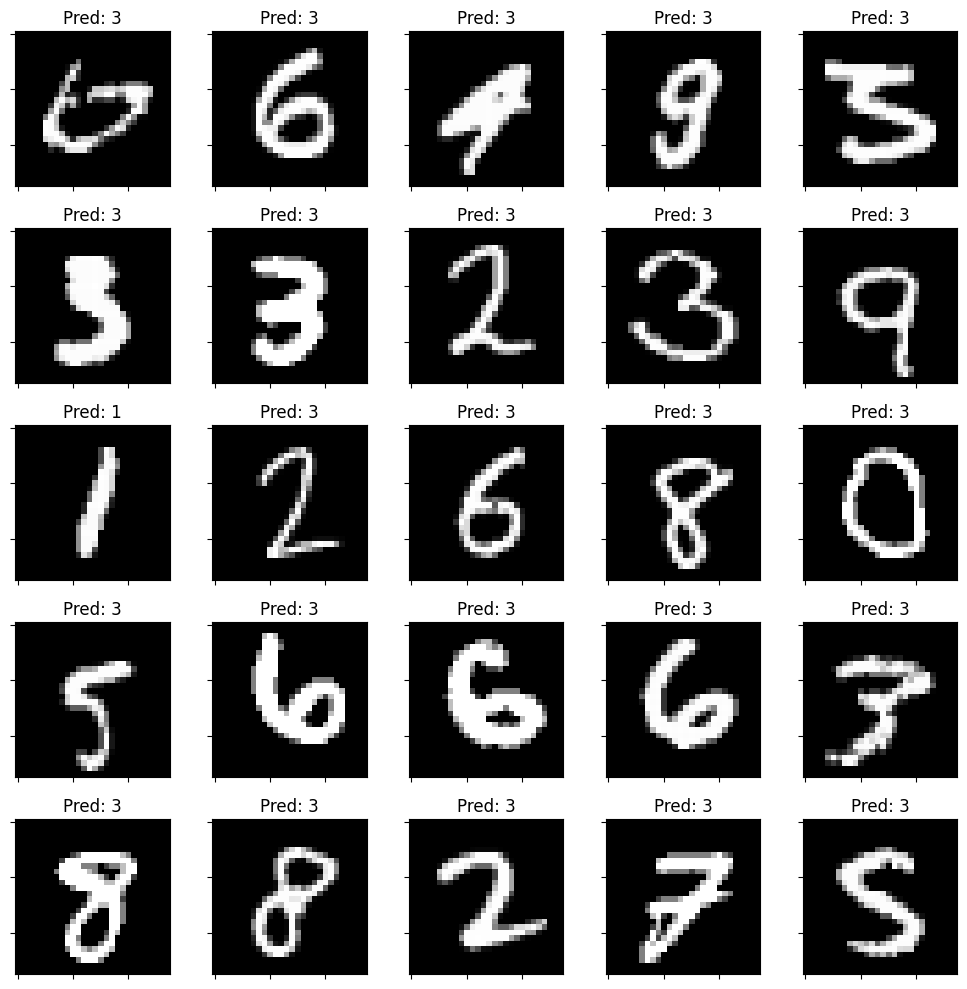

In [25]:
xTestImg = xTest  # already (N, 28, 28)

startIndex = 445
num_row = 5
num_col = 5

fig, axes = plt.subplots(num_row, num_col, figsize=(2*num_col, 2*num_row))
for i in range(num_row * num_col):
    ax = axes[i // num_col, i % num_col]
    ax.imshow(xTestImg[i + startIndex, :, :], cmap="gray")
    ax.set_title(f"Pred: {int(classLabel[i + startIndex])}")
    ax.tick_params(labelbottom=False, labelleft=False)

plt.tight_layout()
plt.show()


# View the predictions after reshaping the flattened images.


In [26]:
xTestImg = np.reshape(xTest, [-1,28,28])

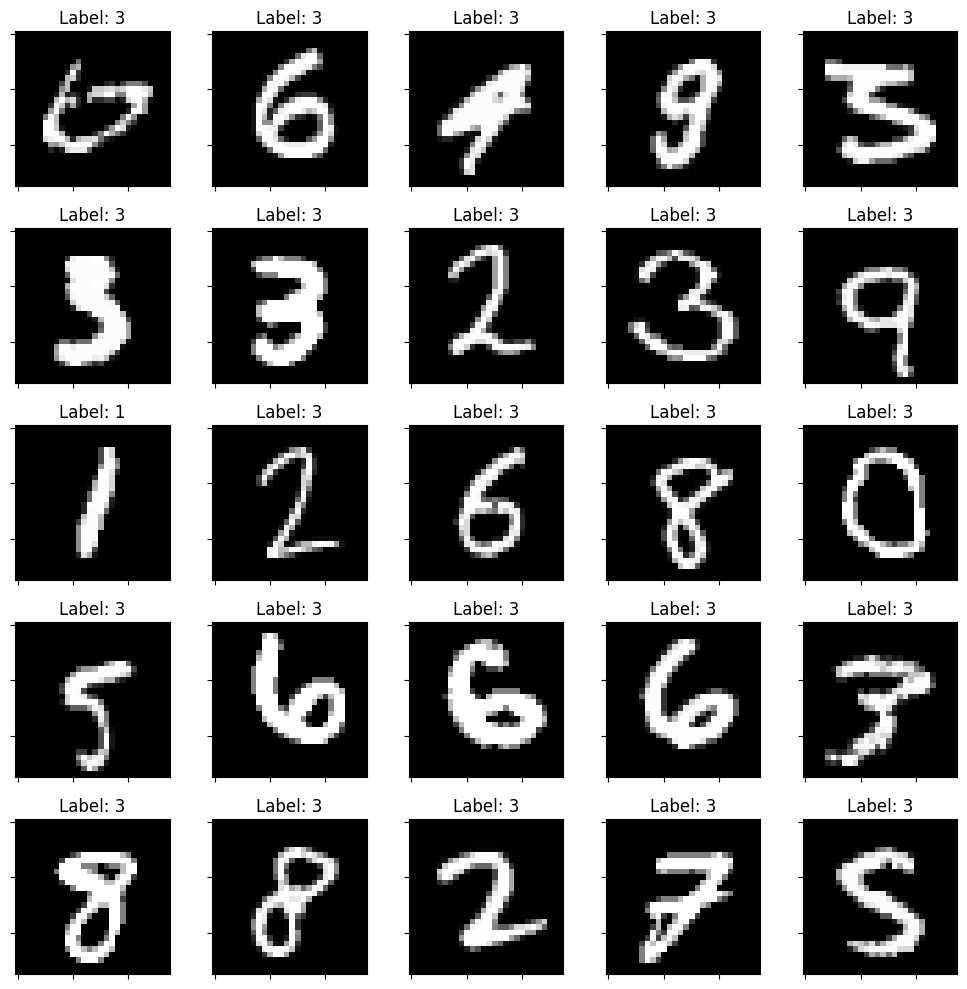

In [27]:
startIndex = 445
num_row = 5
num_col = 5# plot images
fig, axes = plt.subplots(num_row, num_col, figsize=(2*num_col,2*num_row))
for i in range(25):
    ax = axes[i//num_col, i%num_col]
    ax.imshow(xTestImg[i+startIndex,:,:], cmap='gray')
    ax.set_title('Label: {}'.format(classLabel[i+startIndex]))
    ax.tick_params(labelbottom=False)
    ax.tick_params(labelleft=False)
plt.tight_layout()
plt.show()